#  Film Industry Analysis for Business Expansion 

##  **Introduction**  
As part of a company's expansion into the entertainment industry, they are exploring the creation of a new movie studio. However, with no prior experience in film production, it is critical to make data-driven decisions about the types of movies to develop.  

In this project, I will analyze movie industry data to answer key business questions:  
- *Which movie genres tend to receive the highest ratings?* 
- *Which genres have the highest return on investment (ROI)?*
- *Are certain directors more likely to deliver high foreign box office success?*  
- *Which film languages are associated with higher popularity?*  

The goal is to uncover patterns and insights that will help guide the company's decisions on what types of films to produce for maximum commercial success.


## 【1】**Data Exploration**  

### *Loading Datasets*
It is crucial we thoroughly explore each of our datasets and database tables. The datasets we are working with include:
- `Box Office Mojo`
- `IMDB`
- `Rotten Tomatoes Movies`
- `Rotten Tomatoes Critic Reviews`
- `TheMovieDB`
- `The Numbers`
- `im.db` (SQLite database)

Data exploration helps us understand the structure, quality, and characteristics of the data we are working with.  
By examining distributions, missing values, duplicates, and relationships between variables, we can identify potential issues early and plan our cleaning and transformation strategies more effectively.  
This step ensures that our later analyses are based on a solid understanding of the data, reducing the risk of errors and unexpected results.



In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Establish a connection to the database
conn = sqlite3.connect('Data/im.db')

# Check available tables (optional, good for understanding structure)
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)


,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [4]:
# Close connection
conn.close()

Load all Datasets into Pandas Dataframes:

In [5]:
bom_df = pd.read_csv('Data/bom.movie_gross.csv')
bom_df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [6]:
rt_rev_df = pd.read_csv('Data/rt_critic_reviews.csv')
rt_rev_df.head()

,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...
3,m/0814255,Ben McEachen,False,Sunday Mail (Australia),Fresh,3.5/5,2010-02-09,Whether audiences will get behind The Lightnin...
4,m/0814255,Ethan Alter,True,Hollywood Reporter,Rotten,NaN,2010-02-10,What's really lacking in The Lightning Thief i...


In [7]:
rt_df = pd.read_csv('Data/rt_movies.csv')
rt_df.head()

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3


In [8]:
tmdb_df = pd.read_csv('Data/tmdb.movies.csv')
tmdb_df.head()

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


In [9]:
tn_df = pd.read_csv('Data/tn.movie_budgets.csv')
tn_df.head()

,id,release_date,movie,production_budget,domestic_gross,worldwide_gross
0,1,"Dec 18, 2009",Avatar,"$425,000,000","$760,507,625","$2,776,345,279"
1,2,"May 20, 2011",Pirates of the Caribbean: On Stranger Tides,"$410,600,000","$241,063,875","$1,045,663,875"
2,3,"Jun 7, 2019",Dark Phoenix,"$350,000,000","$42,762,350","$149,762,350"
3,4,"May 1, 2015",Avengers: Age of Ultron,"$330,600,000","$459,005,868","$1,403,013,963"
4,5,"Dec 15, 2017",Star Wars Ep. VIII: The Last Jedi,"$317,000,000","$620,181,382","$1,316,721,747"


After successfully loading all the datasets using pandas, we are now ready to dive deeper into data exploration. Given that we are working with six distinct datasets and a database, manually using `.info()`, `.describe()`, `.isna()`, and writing separate code blocks to inspect every dataframe would be highly inefficient, tedious and extremely confusing. Moreover, for the `im.db` database, exploring each table one by one through traditional code would have required an overwhelming amount of setup, making the process unnecessarily complex.

To overcome this, we identified tools that allowed us to explore our data in a far more efficient and highly visual manner.  


### *Data Exploration with Data Wrangler and SQLite Viewer*

For the initial exploration of our datasets, we utilized two powerful Visual Studio Code extensions: 

`Data Wrangler` made early-stage data exploration much faster and more intuitive by providing:
- Visual summaries of column distributions and data types.
- Instant detection of missing values, outliers, and duplicates.
- Quick sorting, filtering, and grouping operations without needing to write code.
- Profiling of datasets with automated suggestions for cleaning and transformation.

`SQLite Viewer` allowed us to efficiently browse the database structure and contents without having to write extensive SQL queries.  
With it, we could:
- Instantly preview tables, columns, and sample data.
- Navigate between tables and their relationships quickly.
- Understand data volumes, missing values, and schema designs in a highly visual and interactive way.

Using `Data Wrangler` and `SQLite Viewer` streamlined our workflow significantly.  
Instead of manually traversing large datasets and databases line-by-line in code, we were able to focus our time on identifying meaningful issues, relationships, and insights

<div style="white-space: nowrap; overflow-x: auto;">
    <img src="images/bom_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/rt_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/rt_rev_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/tmdb_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/tn_df.png" style="display: inline-block; height: 500px; margin-right: 10px;">
    <img src="images/im.db.png" style="display: inline-block; height: 500px; margin-right: 10px;">
</div>

After thorough exploration and exhaustive discussion of the datasets, we carefully evaluated the available columns. Based on importance to our project goals and quality, we decided on a final set of columns that would be most effective for a meaningful analysis:

- From `rotten_tomatoes`:
  - `movie_title`, `genres`, `tomatometer_rating`, `audience_rating`  
    → These columns help us evaluate which movie genres tend to receive the highest critical and audience ratings.

- From `tmdb`:
  - `language`, `popularity`  
    → These attributes allow us to investigate how a film's language impacts its popularity and, by extension, potential profitability.

- From `the_numbers`:
  - `movie`, `production_budget`, `worldwide_gross`  
    → These financial figures are crucial for calculating Return on Investment (ROI) and understanding broader profitability patterns across genres.

- From `im.db`:
  - Extracting and joining data across the `directors`, `persons`, and `movie_akas` tables  
    → This allows us to match each director with the correct movie title, enabling the analysis of which directors tend to deliver high foreign box office success.

Our data exploration confirmed that the columns we selected had either zero or extremely low missing values and were populated with a wide range of distinct entries, indicating that the data quality was high and free from placeholder values.
Even though these are the specific columns we are interested in, it is still necessary to properly prepare and relate the data across different datasets to build a strong foundation for answering the business questions effectively.  


### Key Notes

- **Replacement of Rotten Tomatoes Dataset:**  
  We did not use the originally provided Rotten Tomatoes datasets, as they were inadequate for our analysis.  
  The main relationship between all datasets is the `movie title`, and the provided Rotten Tomatoes tables were missing the movie title column entirely.  
  To ensure consistency and completeness, we imported a more reliable Rotten Tomatoes dataset from [Kaggle](https://www.kaggle.com/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset?select=rotten_tomatoes_movies.csv).

- **Exclusion of Box Office Mojo and Rotten Tomatoes Critic Reviews:**  
  We decided not to use the Box Office Mojo dataset because its information overlapped significantly with The Numbers dataset, which had more complete and reliable financial data.  
  Similarly, the Rotten Tomatoes Critic Reviews dataset was not utilized, as the Rotten Tomatoes Movies Info dataset already provided all the necessary critical and audience rating information for our needs.


## 【2】**Data Preparation & Cleaning**  

Before conducting meaningful analysis, it is essential to properly prepare and clean the data. Even though our data exploration confirmed that we are working with high-quality datasets. Since our datasets come from a variety of origins. Preparation involves filtering relevant columns, renaming fields for consistency, handling duplications, and merging datasets where necessary.  

### **Preparing Rotten Tomatoes Ratings and Genres Data**

To explore the relationship between movie genres, ratings, and their potential connection to success,  
we will prepare and clean the `Rotten Tomatoes Movies` dataset. This dataset provides detailed metadata for a wide range of movies collected from the Rotten Tomatoes website, including information that will be essential for answering our business questions regarding audience perception and genre trends.

#### *Extracting Ratings and Genres Data*

We focus on extracting four key columns from the dataset, which are essential for analyzing movie success and audience perception. The columns we are interested in are:

- `movie_title`: The title of the movie as listed on Rotten Tomatoes.
- `genres`: A comma-separated list of genres assigned to each movie (e.g., Drama, Comedy, Action).
- `audience_rating` The average rating given by the audience, typically scored from 0 to 100.
- `tomatometer_rating` The percentage of positive critic reviews.

When preparing this data, we must be mindful of movies being associated with multiple genres, which requires careful parsing to ensure accurate representation. 

In [10]:
# Extracting the relevant columns
df_rt = rt_df[["movie_title","genres","audience_rating","tomatometer_rating"]].copy()

# Convert the comma-separated string into a list
df_rt['genres'] = df_rt['genres'].str.split(', ')

# Exploding the genres
rt_movies_exploded = df_rt.explode('genres').reset_index(drop=True)
rt_movies_exploded.head()

,movie_title,genres,audience_rating,tomatometer_rating
0,Percy Jackson & the Olympians: The Lightning T...,Action & Adventure,53.0,49.0
1,Percy Jackson & the Olympians: The Lightning T...,Comedy,53.0,49.0
2,Percy Jackson & the Olympians: The Lightning T...,Drama,53.0,49.0
3,Percy Jackson & the Olympians: The Lightning T...,Science Fiction & Fantasy,53.0,49.0
4,Please Give,Comedy,64.0,87.0


We **explode** the `genres` column so that each genre becomes a separate row. This transformation turns one-to-many relationships into one-to-one, making it easier to analyze the data by individual genre. After exploding the column, we should reset the index to clean up the DataFrame and ensure the data is well-organized.



In [11]:
# Comparing the number of rows for main df and the exploded df 
print(f"main: {rt_df.shape[0]} rows")
print(f"exploded: {rt_movies_exploded.shape[0]} rows")


main: 17712 rows
exploded: 39388 rows


Comparing the number of rows in the original DataFrame with the number of rows in the exploded DataFrame helps us confirm that multiple genres per movie were successfully separated into individual rows. An increase in the number of rows indicates that the transformation was successful.

In [12]:
# Seeing if the number of unique movie_title values matches with the main
print(f"exploded: {len(rt_movies_exploded['movie_title'].unique())} unique values")
print(f"main df: {len(rt_df['movie_title'].unique())} unique values")


exploded: 17106 unique values
main df: 17106 unique values


We verify that the number of unique `movie_title` entries remain consistent between the original and exploded datasets. This confirms that the process of exploding the genres did not result in any accidental duplication or loss of movies.


#### *Data Cleaning*

From our earlier data exploration, we confirmed that the columns we are focusing on - `genres`, `audience_rating`, and `tomatometer_rating` contain no duplicates or placeholders. Each column has distinct values, ensuring the data is well-structured. However, we also observed that there are between 0% to 1% of missing values in these columns. Since these missing values are minimal, we can handle them appropriately without significantly affecting the accuracy of our cleaned dataset. In this case, dropping these rows will not reduce the dataset's integrity.

In [13]:
# Checking if missing values align with data exploration findings
(rt_movies_exploded.isna().sum()/len(rt_movies_exploded)*100)

movie_title           0.000000
genres                0.048238
audience_rating       1.241495
tomatometer_rating    0.233574
dtype: float64

Our check confirms that the missing values align with our previous findings. We can now proceed with dropping the rows containing missing values.

In [14]:
# Dropping rows with missing values under 'genres', 'audience_rating', and 'tomatometer_rating'
rt_movies_exploded_cleaned = (
    rt_movies_exploded
    .dropna(subset=["genres", "audience_rating", "tomatometer_rating"])
    .reset_index(drop=True)
)

# Checking if there are any missing values left
rt_movies_exploded_cleaned.isna().sum()


movie_title           0
genres                0
audience_rating       0
tomatometer_rating    0
dtype: int64

#### *Checking for Outliers*

Outliers can skew our analysis and lead to inaccurate results. Identifying and handling them ensures the data better reflects overall trends.

We will use the Interquartile Range (IQR) method to check for outliers:
- **IQR = Q3 - Q1**
- Any data point below **Q1 - 1.5 * IQR** or above **Q3 + 1.5 * IQR** is considered an outlier.

We will apply this logic to `audience_rating` and `tomatometer_rating`



In [15]:
# Checking for outliers
def check_outliers(q1,q3,min,max):
    iqr=q3-q1
    upper_bound=q3+(1.5*iqr)
    lower_bound=q1-(1.5*iqr)
    if (min>lower_bound) & (max<upper_bound):
     return("There are no outliers")
    else:
     return("There are outliers")
 
# Checking in the audience_rating column
print(f"{check_outliers(q1=46,q3=78,min=0,max=100)} in the audience rating column")

# Checking in the tomatometer_rating column
print(f"{check_outliers(q1=40,q3=86,min=0,max=100)} in the tomatometer rating column")


There are no outliers in the audience rating column
There are no outliers in the tomatometer rating column


#### *Standardizing text columns*
Standardization helps avoid inconsistencies during grouping, searching, or filtering. (e.g., "Drama" and "drama" would otherwise be treated differently). We standardize text data by converting `movie_title` and `genres` columns to lowercase.


In [16]:
# Making sure to work on a copy to avoid the SettingWithCopyWarning
rt_movies_exploded_cleaned = rt_movies_exploded_cleaned.copy()

# Standardizing columns to lowercase
rt_movies_exploded_cleaned["genres"] = rt_movies_exploded_cleaned["genres"].str.lower()
rt_movies_exploded_cleaned["movie_title"] = rt_movies_exploded_cleaned["movie_title"].str.lower()

rt_movies_exploded_cleaned.head()

,movie_title,genres,audience_rating,tomatometer_rating
0,percy jackson & the olympians: the lightning t...,action & adventure,53.0,49.0
1,percy jackson & the olympians: the lightning t...,comedy,53.0,49.0
2,percy jackson & the olympians: the lightning t...,drama,53.0,49.0
3,percy jackson & the olympians: the lightning t...,science fiction & fantasy,53.0,49.0
4,please give,comedy,64.0,87.0


#### *Aggregating Ratings by Genre*

To better understand how different genres perform on average with audiences and critics, we grouped the cleaned dataframe by genre and calculated the mean of both the audience ratings and the tomatometer ratings. This aggregation helps us identify broader trends and preferences across movie genres, rather than focusing on individual movie performances.


In [17]:
# Grouping by genres and aggregating the mean of audience_rating and tomatometer_rating
genre_rating_df = rt_movies_exploded_cleaned.groupby('genres').agg({
    'audience_rating': 'mean',
    'tomatometer_rating': 'mean'
}).reset_index()

# Formatting the ratings to show only one decimal place
genre_rating_df['audience_rating'] = genre_rating_df['audience_rating'].round(1)
genre_rating_df['tomatometer_rating'] = genre_rating_df['tomatometer_rating'].round(1)

genre_rating_df


,genres,audience_rating,tomatometer_rating
0,action & adventure,57.9,54.2
1,animation,65.7,64.1
2,anime & manga,75.0,75.4
3,art house & international,66.5,71.0
4,classics,71.0,78.4
5,comedy,58.4,55.1
6,cult movies,55.8,60.5
7,documentary,73.3,80.9
8,drama,63.1,63.2
9,faith & spirituality,70.3,63.9


In [18]:
# Confirming no genres were lost after aggregation
len(rt_movies_exploded_cleaned['genres'].value_counts()) == len(genre_rating_df)

True

### **Preparing Genres and ROI Data** 

In this section, we will focus on preparing two key components: **genres** and **Return on Investment (ROI)**. Both are essential for understanding the financial success and audience preferences of movies.

We will use:
- `tn.movie_budgets`: This table contains information on the `Production Budget`, `Worldwide Gross`, and the engineered `ROI` column.
- `rt_movies`: This table provides the `Genres` associated with each movie.

**Genres** provide valuable insight into the themes and categories that resonate most with audiences, while **ROI** helps us assess the profitability of each movie relative to its production cost. By calculating and analyzing ROI alongside genres, we can identify which genres are the most profitable and thus prioritize them for future movie production.




#### *Merging Appropriate Tables*

We will merge the `tn.movie_budgets` dataset (which contains production budgets and worldwide gross revenue) with the `rt_movies` dataset (which includes genre information). The key idea is to join these datasets on the **movie title** to create a consolidated table that includes both **genres** and **ROI** for each movie.

In [19]:
# Prepare movie titles for better matching (remove special characters, lower case)
tn_df['movie'] = tn_df['movie'].str.strip().str.lower()
rt_df['movie_title'] = rt_df['movie_title'].str.strip().str.lower()

# Merge the datasets on the appropriate columns
merged_df = tn_df.merge(rt_df[['movie_title', 'genres']], left_on='movie', right_on='movie_title', how='left')

# Drop duplicate movie_title column if you want
merged_df = merged_df.drop(columns=['movie_title'])

merged_df.head()


,id,release_date,movie,production_budget,domestic_gross,worldwide_gross,genres
0,1,"Dec 18, 2009",avatar,"$425,000,000","$760,507,625","$2,776,345,279","Action & Adventure, Comedy, Mystery & Suspense..."
1,2,"May 20, 2011",pirates of the caribbean: on stranger tides,"$410,600,000","$241,063,875","$1,045,663,875","Action & Adventure, Comedy, Science Fiction & ..."
2,3,"Jun 7, 2019",dark phoenix,"$350,000,000","$42,762,350","$149,762,350","Action & Adventure, Drama, Science Fiction & F..."
3,4,"May 1, 2015",avengers: age of ultron,"$330,600,000","$459,005,868","$1,403,013,963","Action & Adventure, Science Fiction & Fantasy"
4,5,"Dec 15, 2017",star wars ep. viii: the last jedi,"$317,000,000","$620,181,382","$1,316,721,747",NaN


#### *ROI Computation*

In this step, we aim to calculate the **Return on Investment (ROI)** for each movie. ROI is a key financial metric that helps us assess the profitability of a film relative to its production cost. By calculating the ROI for each movie, we can better understand which films have been the most financially successful and use that insight to inform future production decisions.

The calculation of ROI will be based on the formula:

**ROI = (Worldwide Gross - Production Budget) ÷ Production Budget × 100**


In [20]:
# Clean up the dollar signs and commas and convert columns to numeric
merged_df['production_budget'] = merged_df['production_budget'].replace([r'[\$,]'], '', regex=True).astype(float)
merged_df['worldwide_gross'] = merged_df['worldwide_gross'].replace([r'[\$,]'], '', regex=True).astype(float)

# Calculate ROI
merged_df['ROI (%)'] = ((merged_df['worldwide_gross'] - merged_df['production_budget']) / merged_df['production_budget']) * 100

# Round ROI to nearest whole number
merged_df['ROI (%)'] = merged_df['ROI (%)'].round()

# Group by 'movie' and calculate the mean ROI (though each movie is unique here)
roi_grouped = merged_df.groupby('movie')[['ROI (%)']].mean().reset_index()

# Final table: Comparison between genres and the grouped movie ROI
final_table = merged_df[['genres', 'movie']].merge(roi_grouped, on='movie')

final_table.isna().sum()

genres     1264
movie         0
ROI (%)       0
dtype: int64

#### Handling Missing Values 

In [21]:
final_table.isna().sum()

genres     1264
movie         0
ROI (%)       0
dtype: int64

Since the `genres` column has 1264 missing values and is crucial for our analysis, we will drop these rows as they do not provide useful information for our objectives.

In [22]:
final_table.dropna(subset=['genres'], inplace=True)

#### *Expanding Movies into Individual Genres*

We aim to break down each movie's genre information to better understand how individual genres contribute to a movie's success. Since movies can belong to multiple genres, expanding the dataset to reflect each genre individually will allow us to analyze the performance of each genre separately.

By doing so, we can identify which genres tend to perform better financially and make more informed decisions about which genres to prioritize in future film productions.


In [23]:
# Split genres into a list
final_table['genres'] = final_table['genres'].str.split(',')

# Explode the list into separate rows
exploded_table = final_table.explode('genres')

# Remove extra spaces around genre names
exploded_table['genres'] = exploded_table['genres'].str.strip()

exploded_table


,genres,movie,ROI (%)
0,Action & Adventure,avatar,553.0
0,Comedy,avatar,553.0
0,Mystery & Suspense,avatar,553.0
0,Science Fiction & Fantasy,avatar,553.0
1,Action & Adventure,pirates of the caribbean: on stranger tides,155.0
...,...,...,...
6223,Mystery & Suspense,following,3908.0
6226,Comedy,my date with drew,16358.0
6226,Documentary,my date with drew,16358.0
6226,Special Interest,my date with drew,16358.0


#### *Cleaning and Grouping by Genres*

We aim to clean the data and group the movies by their genres to calculate the average Return on Investment (ROI) for each genre. Cleaning the data ensures that we remove any rows with missing or invalid information, which could distort our analysis. Sorting the data by ROI will help us identify the top-performing genres, providing valuable information for future movie production decisions.


In [24]:
# Drop rows with NULLs in important columns
exploded_table = exploded_table.dropna(subset=['genres', 'movie', 'ROI (%)'])

# Group by 'genres' and calculate average ROI
grouped_table = exploded_table.groupby('genres')['ROI (%)'].mean().reset_index()

# Sort by ROI in descending order
grouped_table = grouped_table.sort_values(by='ROI (%)', ascending=False)

# Reset index to clean it up
grouped_table = grouped_table.reset_index(drop=True)

grouped_table.head()

,genres,ROI (%)
0,Cult Movies,4669.958333
1,Horror,975.298217
2,Special Interest,932.209677
3,Documentary,868.586466
4,Classics,839.873684


### **Preparing Language and Popularity Data**

To support the company's goal of identifying the most successful types of films at the box office, we begin by analyzing two key variables from *The Movie DB* dataset: `original_language` and `popularity`. The `original_language` column helps us understand which linguistic markets (e.g., English, Spanish, etc.) dominate box office performance, guiding strategic decisions about which language(s) to prioritize in production—either to reach the broadest audience or to tap into emerging markets. The `popularity` column serves as a proxy for viewer engagement and interest, offering insight into which films generate buzz and traction among audiences. By examining both these variables, we can uncover patterns between language, popularity, and potential box office success. 

Before diving into the data preparation, let’s quickly glance at the first few rows of the dataset to visually remind ourselves of what we’re working with.

In [25]:
tmdb_df.head(5)

,Unnamed: 0,genre_ids,id,original_language,original_title,popularity,release_date,title,vote_average,vote_count
0,0,"[12, 14, 10751]",12444,en,Harry Potter and the Deathly Hallows: Part 1,33.533,2010-11-19,Harry Potter and the Deathly Hallows: Part 1,7.7,10788
1,1,"[14, 12, 16, 10751]",10191,en,How to Train Your Dragon,28.734,2010-03-26,How to Train Your Dragon,7.7,7610
2,2,"[12, 28, 878]",10138,en,Iron Man 2,28.515,2010-05-07,Iron Man 2,6.8,12368
3,3,"[16, 35, 10751]",862,en,Toy Story,28.005,1995-11-22,Toy Story,7.9,10174
4,4,"[28, 878, 12]",27205,en,Inception,27.920,2010-07-16,Inception,8.3,22186


During the data exploration phase, we utilized the Data Wrangler tool to inspect the columns of interest: `original_language` and `popularity`. Thanks to this thorough exploration, we confirmed that both columns had no missing values, ensuring that our analysis would proceed without any gaps in the data.


#### *Handling Outliers in Popularity Scores*

Before extracting the relevant columns for analysis, it's important to address a key data quality issue: outliers in the `popularity` column. Outliers can distort statistical measures like the mean. Since our goal is to calculate the average popularity for each language, the presence of outliers could lead to misleading conclusions about which languages are genuinely associated with higher audience engagement.

To ensure a more statistically accurate analysis, we use the Interquartile Range (IQR) method to detect and remove these extreme values. This step helps us reduce noise in the data and obtain a more representative average popularity per language.

In [26]:
# Calculating IQR to detect outliers in the 'popularity' column
Q1 = tmdb_df['popularity'].quantile(0.25)
Q3 = tmdb_df['popularity'].quantile(0.75)
IQR = Q3 - Q1

# Defining lower and upper bounds for acceptable data
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the dataset to exclude outliers
tmdb_df_no_outliers = tmdb_df[
    (tmdb_df['popularity'] >= lower_bound) & (tmdb_df['popularity'] <= upper_bound)
]

print(f"Number of rows before removing outliers: {tmdb_df.shape[0]}")
print(f"Number of rows after removing outliers: {tmdb_df_no_outliers.shape[0]}")

Number of rows before removing outliers: 26517
Number of rows after removing outliers: 23988


After removing the outliers, we can see a reduction in the number of rows in the dataset, confirming that the outlier removal process was successful. This ensures that our analysis will be based on more reliable data.

#### *Grouping and Aggregating Language Popularity Data*
We will isolate the two relevant columns: `original_language` and `popularity`. However, simply extracting these columns isn’t enough—we need to summarize the data to identify broader trends. To do this, we group the dataset by `original_language` and calculate the average `popularity` score for each language. This aggregation allows us to see which languages, on average, are associated with higher popularity and may therefore represent more promising markets for film production.

In [27]:
# Grouping by 'original_language' and calculating the average 'popularity'
language_popularity_avg = (
    tmdb_df[['original_language', 'popularity']]
    .groupby('original_language', as_index=False)
    .agg(average_popularity=('popularity', 'mean'))
)

# Round the average popularity to 1 decimal place
language_popularity_avg['average_popularity'] = language_popularity_avg['average_popularity'].round(1)

language_popularity_avg.head()



,original_language,average_popularity
0,ab,1.0
1,af,4.8
2,ar,2.7
3,bg,1.0
4,bn,1.2


#### *Key Assumption & Realization*

Our initial assumption was that the `popularity` score reflected the popularity of films within specific languages. However, upon further inspection of the data after preparation, we realized that the `popularity` score actually pertains to the individual movie's popularity, rather than being language-specific. This discovery means that our conclusions regarding language popularity may be subject to some inaccuracy, as the `popularity` score is influenced by a variety of factors beyond language, such as genre, cast, and marketing. This nuance must be kept in mind when interpreting the results of our analysis.


### **Preparing Directors and Foreign Gross Data**

We will prepare and align two datasets to explore the relationship between directors and the worldwide gross earnings of their movies. From our earlier data exploration, we have confirmed that there are no missing values in the relevant `im.db` tables and in `the Numbers movie budgets` dataset, which will allow us to proceed without needing additional imputation steps. Since these datasets originate from different sources and structures, we will need to carefully filter and merge them to ensure accuracy.  

#### *Extracting Director and Movie Title Data*

We will start by extracting a clean dataset containing each director's name and their corresponding movie title from the `im.db` database. However the `directors` table contains identifiers (IDs) that point to other tables for the necessary information. Specifically, the director's name is not stored directly in the `directors` table but rather in the `persons` table. Additionally, the movie title is stored in the `movie_akas` table, which links movies to their various titles across different regions.

To ensure we retrieve only unique director–movie pairs, we are using a `DISTINCT` query.  
During earlier exploration, we noticed several duplicate entries caused by the way data was entered into the database, so applying `DISTINCT` helps eliminate these redundancies by focusing only on original movie titles.


In [28]:
# Connect to the database
conn = sqlite3.connect('Data/im.db')

# Updated query with DISTINCT
query = '''
SELECT DISTINCT
    p.primary_name AS director_name,
    ma.title AS movie_title
FROM directors d
JOIN persons p ON d.person_id = p.person_id
JOIN movie_akas ma ON d.movie_id = ma.movie_id
WHERE ma.is_original_title = 1
'''

# Execute the query and load into a DataFrame
directors_df = pd.read_sql_query(query, conn)

# Close connection
conn.close()
directors_df.head()


,director_name,movie_title
0,Colin Trevorrow,Jurassic World
1,Andrew Stanton,John Carter
2,Marc Jampolsky,Versailles Rediscovered - The Sun King's Vanis...
3,Sam Zubrycki,Miguelito - Canto a Borinquen
4,Henning Beckhoff,Thing I Don't Get


#### *Merging Directors with Worldwide Gross Data*

We need to combine the director information with the worldwide gross earnings.  
This step ensures that each movie in our dataset is matched with both its director and its revenue performance, setting the foundation for meaningful analysis.


In [29]:
# Rename for easy merge
directors_df = directors_df.rename(columns={'movie_title': 'movie'})

# Merge the two DataFrames
merged_df = pd.merge(tn_df[['movie', 'worldwide_gross']], directors_df, on='movie', how='inner')

# Reorder columns
directors_fgross_df = merged_df[['movie', 'director_name', 'worldwide_gross']]

# Sort alphabetically by director name
directors_fgross_df = directors_fgross_df.sort_values(by='director_name').reset_index(drop=True)
directors_fgross_df


,movie,director_name,worldwide_gross
0,3,Aishwarya Dhanush,"$295,492"
1,42,Brian Helgeland,"$97,470,701"
2,9,Claude Brie,"$48,559,999"
3,9,Erik Canuel,"$48,559,999"
4,21,Jaishankar Chigurula,"$159,846,429"
5,9,Jean-Philippe Duval,"$48,559,999"
6,50 to 1,Jim Wilson,"$1,069,454"
7,50/50,Jonathan Levine,"$41,334,735"
8,3,Lou Simon,"$295,492"
9,9,Luc Picard,"$48,559,999"


#### *Aggregating Worldwide Gross Earnings by Director*

We need to aggregate the data to account for the fact that a single director may have multiple movies. Our goal is to sum up the worldwide gross earnings for each director across all their movies, creating a table that shows the total earnings per director. This aggregation will give us a clearer picture of each director's overall financial impact.


In [30]:
# Remove commas, dollar sign and convert to float for calculation
directors_fgross_df['worldwide_gross'] = directors_fgross_df['worldwide_gross'].replace(r',', '', regex=True)
directors_fgross_df['worldwide_gross'] = directors_fgross_df['worldwide_gross'].replace(r'\$', '', regex=True).astype(float)

# Group by director_name and sum worldwide_gross
agg_directors_df = directors_fgross_df.groupby('director_name', as_index=False)['worldwide_gross'].sum()

# Sort by worldwide_gross in descending order
agg_directors_df = agg_directors_df.sort_values(by='worldwide_gross', ascending=False).reset_index(drop=True)

# Format numbers with commas 
agg_directors_df['worldwide_gross'] = agg_directors_df['worldwide_gross'].apply(lambda x: f"{int(x):,}")
agg_directors_df


,director_name,worldwide_gross
0,Jaishankar Chigurula,"159,846,429"
1,Brian Helgeland,"97,470,701"
2,Luc Picard,"48,559,999"
3,Stéphane E. Roy,"48,559,999"
4,Ricardo Trogi,"48,559,999"
5,Micheline Lanctôt,"48,559,999"
6,Marc Labrèche,"48,559,999"
7,Éric Tessier,"48,559,999"
8,Jean-Philippe Duval,"48,559,999"
9,Erik Canuel,"48,559,999"


### **Preparing Content Rating and ROI Data**

Understanding the relationship between a film’s content rating (such as G, PG, PG-13, R) and its Return on Investment (ROI) can provide valuable strategic guidance for the company’s new movie studio. Content ratings influence which audiences a movie can legally and culturally reach, and may affect production budgets, marketing strategies, and box office returns.

#### *Merging Dataframes*

To analyze the relationship between content ratings and ROI, we need to combine relevant information from two different sources. We will merge the `final_table`, which already contains ROI calculations and genre data, with the Rotten Tomatoes dataset (`rt_df`), which includes content rating information for each movie. 


In [31]:
# computing the joined df
merged_df = final_table.merge(rt_df[['movie_title', 'content_rating']], left_on='movie', right_on='movie_title', how='left')
merged_df.sample(10)

,genres,movie,ROI (%),movie_title,content_rating
5874,"[Art House & International, Drama]",l.i.e.,63.0,l.i.e.,NC17
2402,[Comedy],the brothers grimsby,-18.0,the brothers grimsby,R
2807,"[Drama, Mystery & Suspense]",kiss the girls,124.0,kiss the girls,R
1798,"[Action & Adventure, Kids & Family, Science ...",journey to the center of the earth,440.0,journey to the center of the earth,PG
979,"[Action & Adventure, Comedy, Science Fiction...",the brothers grimm,32.0,the brothers grimm,PG-13
5184,"[Comedy, Drama]",life during wartime,-94.0,life during wartime,R
4180,[Drama],the drop,51.0,the drop,R
135,"[Kids & Family, Science Fiction & Fantasy]",alice in wonderland,156.5,alice in wonderland,PG
1248,"[Action & Adventure, Documentary, Television...",everest,240.0,everest,PG-13
266,"[Animation, Kids & Family]",big hero 6,295.0,big hero 6,PG


#### *Extracting Relevant Columns*

We are specifically interested in understanding how content rating relates to movie profitability. To keep our dataset focused and manageable, we will extract only two columns: `content_rating` and `ROI (%)`. These columns will allow us to analyze average returns across different rating categories.


In [32]:
# extracting the relevant columns
relevant_columns=["ROI (%)","content_rating"]
rel_joined_df = merged_df[relevant_columns].copy()
rel_joined_df.head(5)

,ROI (%),content_rating
0,553.0,PG-13
1,155.0,PG-13
2,-57.0,PG-13
3,324.0,PG-13
4,583.0,PG-13


#### *Handling Missing Values*

From earlier Data Preparation, we know that `ROI` has no missing values. Here, we check for and drop rows with missing values in `content_rating` to ensure the dataset remains clean and usable.


In [33]:
# checking for missing_values
missing = rel_joined_df.isna().sum()
percent_missing = (missing / len(rel_joined_df))*100
percent_missing

ROI (%)           0.0
content_rating    0.0
dtype: float64

In [34]:
# dropping the rows with missing values
rel_joined_df.dropna(axis=0,subset="content_rating",inplace=True)
rel_joined_df.isna().sum()

ROI (%)           0
content_rating    0
dtype: int64

#### *Aggregating ROI by Content Rating*

To understand how movie profitability varies across different content ratings, we group the data by `content_rating` and compute the average `ROI` for each category. This helps reveal which content ratings are associated with higher financial returns.


In [35]:
# grouping the df
grouped_df = rel_joined_df.groupby("content_rating")["ROI (%)"].mean().reset_index().sort_values(by="ROI (%)",ascending=False)
grouped_df

,content_rating,ROI (%)
0,G,751.944649
2,NR,572.694215
5,R,513.067253
3,PG,486.622322
4,PG-13,257.874652
1,NC17,125.000000


In [36]:
# checking if the groupby captured all categories
len(rt_df['content_rating'].unique())==len(grouped_df)

True

Since the number of categories remain constant after aggregating the columns, we conclude that the groupby captured all the categories in the content rating column.

## 【3】**Data Analysis**  

#### *1. Data Analysis*  

##### Kevin
Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

### **Genre vs Rating EDA**

### **Loading The Relevant Dataframe**

We will be using the cleaned version of the Rotten Tomatoes Movies Dataset.

In [37]:
#extracting relevant columns
rel_rt_df=rt_movies_exploded_cleaned[["genres","audience_rating","tomatometer_rating"]].copy()

### Summarizing The Dataframe
Here we will be doing a summary of the information contained in our relevant dataframe.Summarizing a DataFrame provides a quick overview of its structure, data types, and potential issues. It helps identify missing values, formatting problems, and memory usage.

In [48]:
# summary of df
rel_rt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38853 entries, 0 to 38852
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   genres              38853 non-null  object 
 1   audience_rating     38853 non-null  float64
 2   tomatometer_rating  38853 non-null  float64
dtypes: float64(2), object(1)
memory usage: 910.7+ KB


The dataframe has 38853 rows and 3 columns. There are no missing values. The dataset has a mixture of categorical an numerical columns. all the column values are in the data types we expect them to be

### **Dataframe Description**

we will be describing the numerical columns(tomatometer rating and audince rating). Describing a DataFrame offers a statistical overview of numerical columns, revealing the data’s distribution, variability, and potential outliers. It aids in validating accuracy, assessing skewness, and informing feature engineering decisions.

In [50]:
# describing df
rel_rt_df.describe()

,audience_rating,tomatometer_rating
count,38853.000000,38853.000000
mean,61.547371,62.039302
std,20.367528,28.046879
min,0.000000,0.000000
25%,46.000000,40.000000
50%,64.000000,67.000000
75%,78.000000,86.000000
max,100.000000,100.000000


This table compares the distribution of Audience Ratings and Tomatometer Ratings from a sample of movie reviews, revealing key differences in central tendency, spread, and distribution shape between general audience scores and critic-aggregated ratings. The sample includes 38,853 audience reviews and 38,853 critic scores. On average, audiences rate slightly lower (61.54) than critics (62.03). However, critic ratings show greater variability, with a standard deviation of 28.05 compared to 20.37 for audience ratings. Although both rating scales span from 0 to 100, critics' ratings are more polarized—25% of critic scores fall at or below 40, while 75% of audience scores are at or below 78. Additionally, the median critic rating (67) is higher than the audience median (64), indicating a general tendency for critics to rate films more favorably

### **Correlation Analysis**

We will conduct a pearson's correlation analysis between the audince ratings and the tomatometer ratings to check for their relationship. A correlation coefficient above 0.6 indicates a strong relationship.

In [51]:
# calculating corrcoef
np.corrcoef(rel_rt_df["tomatometer_rating"],rel_rt_df["audience_rating"])[0,1]

0.6672169709939124

We get a correlation of 0.67 indicating a strong positive relationship between the audience ratings and the tomato meter ratings.

### **checking and handling outliers**

We create a funtions to extract dataframe with no outlier values in the audience ratings and tomato meter rating columns for each genre.

In [52]:
# extracting df with no outliers in the audience ratings
def detect_AR_outliers(df=rel_rt_df, aud_col='audience_rating', group_col='genres'):
    """
    Detects and removes ROI outliers within each content rating group using the IQR method.

    Returns:
    - cleaned_df: DataFrame with outliers removed.
    - outliers_df: DataFrame containing only the outliers.
    """
    cleaned_rows = []
    outlier_rows = []

    for category in df[group_col].unique():
        group = df[df[group_col] == category]
        Q1 = group[aud_col].quantile(0.25)
        Q3 = group[aud_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter inliers and outliers
        inliers = group[(group[aud_col] >= lower_bound) & (group[aud_col] <= upper_bound)]
        outliers = group[(group[aud_col] < lower_bound) | (group[aud_col] > upper_bound)]

        cleaned_rows.append(inliers)
        outlier_rows.append(outliers)
        

    cleaned_df = pd.concat(cleaned_rows).reset_index(drop=True)
    return cleaned_df
cleaned_df1=detect_AR_outliers()
cleaned_df1

,genres,audience_rating,tomatometer_rating
0,action & adventure,53.0,49.0
1,action & adventure,74.0,89.0
2,action & adventure,37.0,8.0
3,action & adventure,86.0,96.0
4,action & adventure,82.0,80.0
...,...,...,...
38724,gay & lesbian,46.0,71.0
38725,gay & lesbian,92.0,100.0
38726,gay & lesbian,100.0,96.0
38727,gay & lesbian,72.0,71.0


This funtion deals with the outliers in the audience rating for each genre. it starts by calculating the upper bound and lower bound for a specific genre. it then extracts a dataframe with no outliers for that specific genre using the bounds.It appends the final df into a list.It does this for all the genres and then concatenates all the final list to come up with a dataframe with no outliers. 

In [53]:
print(f"len of original dataframe :{len(rel_rt_df)}")
print(f"len of no outliers dataframe :{len(cleaned_df1)}")

len of original dataframe :38853
len of no outliers dataframe :38729


From the lengths of the original dataframe and the dataframe with no outliers in the audience ratings for each genre,we can see that there is a very small difference between the two hence we proceed to use the dataframe with no outliers

In [54]:
# extract df with no outliers in the tomato meter ratings
def detect_TM_outliers(df=cleaned_df1, tm_col='tomatometer_rating', group_col='genres'):
    """
    Detects and removes ROI outliers within each content rating group using the IQR method.

    Returns:
    - cleaned_df: DataFrame with outliers removed.
    - outliers_df: DataFrame containing only the outliers.
    """
    cleaned_rows = []
    outlier_rows = []

    for category in df[group_col].unique():
        group = df[df[group_col] == category]
        Q1 = group[tm_col].quantile(0.25)
        Q3 = group[tm_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter inliers and outliers
        inliers = group[(group[tm_col] >= lower_bound) & (group[tm_col] <= upper_bound)]
        outliers = group[(group[tm_col] < lower_bound) | (group[tm_col] > upper_bound)]

        cleaned_rows.append(inliers)
        outlier_rows.append(outliers)
        

    cleaned_tm_df = pd.concat(cleaned_rows).reset_index(drop=True)
    return cleaned_tm_df
cleaned_tm_df=detect_TM_outliers()
cleaned_tm_df

,genres,audience_rating,tomatometer_rating
0,action & adventure,53.0,49.0
1,action & adventure,74.0,89.0
2,action & adventure,37.0,8.0
3,action & adventure,86.0,96.0
4,action & adventure,82.0,80.0
...,...,...,...
38441,gay & lesbian,46.0,71.0
38442,gay & lesbian,92.0,100.0
38443,gay & lesbian,100.0,96.0
38444,gay & lesbian,72.0,71.0


This funtion deals with the outliers in the tomato meter rating for each genre. it works in a similar way as the funtion for dealing with outliers in the audience ratings. it does so using the dataframe with no outliers  in the audience ratings.

In [55]:
print(f"len of no AR outliers dataframe :{len(cleaned_df1)}")
print(f"len of no outliers dataframe :{len(cleaned_tm_df)}")

len of no AR outliers dataframe :38729
len of no outliers dataframe :38446


From the lengths of the dataframe in which we had dropped outliers in the audience rating, and the dataframe with no outliers in the tomato meter  ratings for each genre,we can see that there is a very small difference between the two hence we proceed to use the dataframe with no outliers in the tomato meter rating

### **plotting histograms**

A histogram visually represents the distribution of a dataset, making it easy to identify patterns, such as skewness, spread, and outliers.

#### *Distribution of Audience Ratings*

here we will plot a histogram for the audience ratings

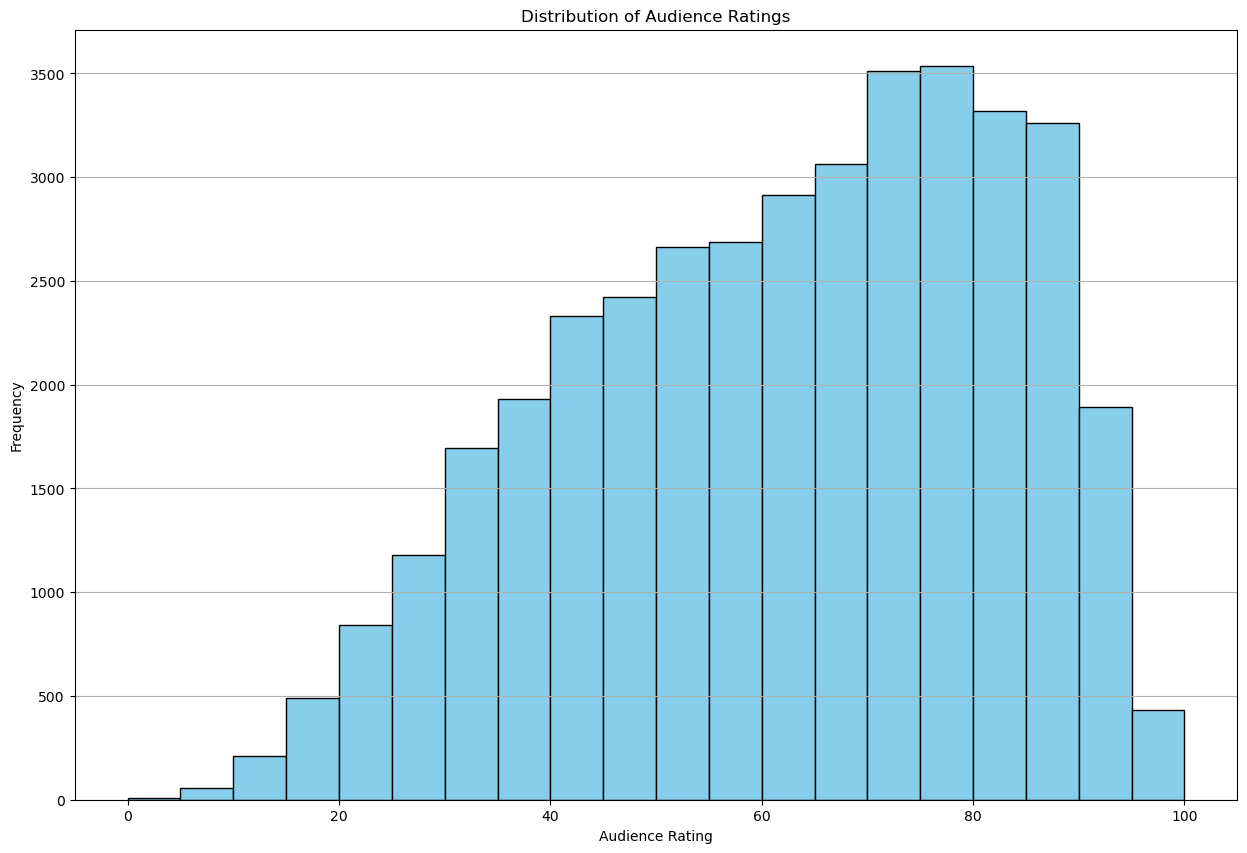

In [56]:
# histogram of distribution of audience ratings
plt.figure(figsize=(15,10))
plt.hist(cleaned_tm_df["audience_rating"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Audience Ratings")
plt.xlabel("Audience Rating")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()

We see that audiences tend to rate movies highly with most ratings clustered on the upper tail. The minimum rating is around 0 while the maximum rating is around 100. Most of the audience ratings were between 70 and 80. And the least ratings between 0 and 5.

#### *Distribution of Tomatometer Ratings*

Here we we will plot a histogram for the tomato meter ratings

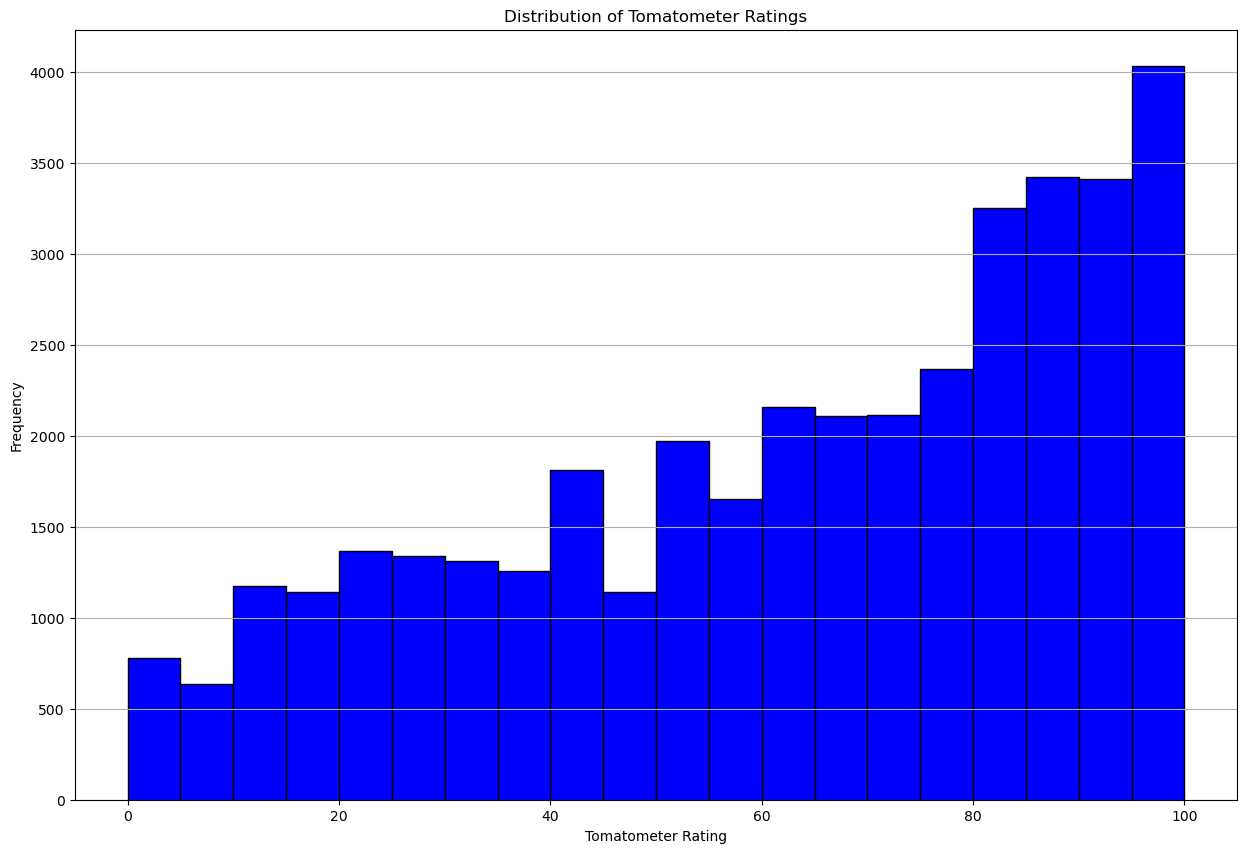

In [57]:
# plot histogram for the distribution of tomato meter ratings
plt.figure(figsize=(15,10))
plt.hist(cleaned_tm_df["tomatometer_rating"], bins=20, color='blue', edgecolor='black')
plt.title("Distribution of Tomatometer Ratings")
plt.xlabel("Tomatometer Rating")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()

We see that the tomato meter also rates movies highly. The ratings are spread out more than the audience ratings. The minimum rating is 0 while the maximum rating is 100. Most of the tomato meter ratings were between 95 and 100. And the least ratings were between 5 and 10.

### **Aggregating Ratings By Genre In The Dataframe With No Outliers**

In [58]:
# Grouping by genres and aggregating the mean of audience_rating and tomatometer_rating
genre_grouped_df =cleaned_tm_df.groupby('genres').agg({
    'audience_rating': 'mean',
    'tomatometer_rating': 'mean'
}).reset_index()

### **Plotting Bar Graphs**

We plot bar graphs to see the spread of values across the different genres.

#### *Genre Vs Audience Rating Bar Graph*

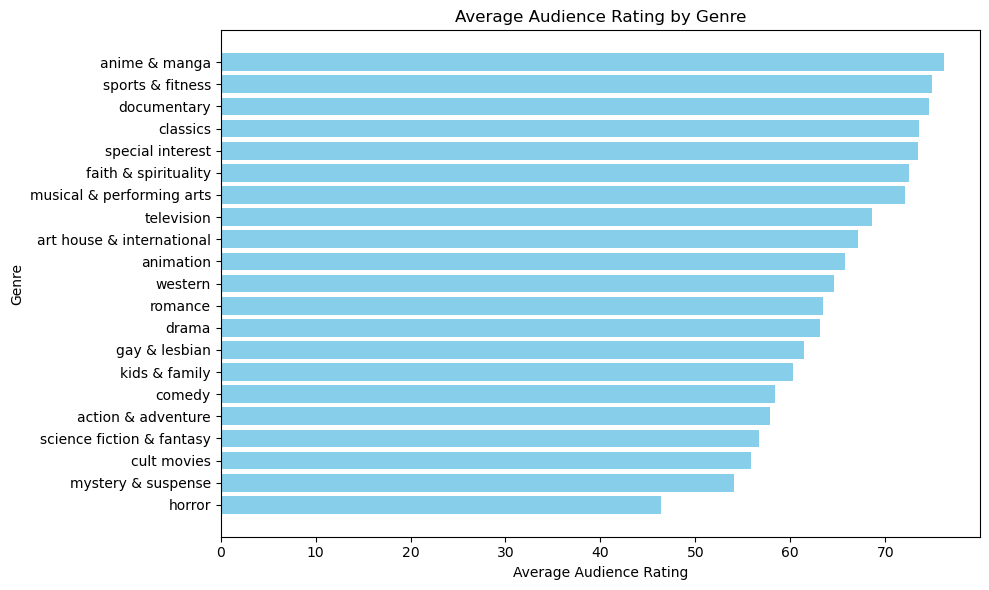

In [60]:
# Sort by audience_rating descending
sorted_genre_grouped_df1 = genre_grouped_df.sort_values(by="audience_rating", ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(y=sorted_genre_grouped_df1["genres"], width=sorted_genre_grouped_df1["audience_rating"], color='skyblue')
plt.xlabel("Average Audience Rating")
plt.ylabel("Genre")
plt.title("Average Audience Rating by Genre")
plt.gca().invert_yaxis()  # Optional: highest rating appears at the top
plt.tight_layout()
plt.show()

The top rated genres by audiences are `anime & manga`, `sports and fitness`,`documentary`,`classics`,`special interest`,`faith and spirituality` and  `musical and perfoming arts` respectively.

The least rated genres by audiences are `horror` followed by `mystery and suspense`  and `cult movies`

#### *Genre Vs Tomato Meter Rating Bar Graph*

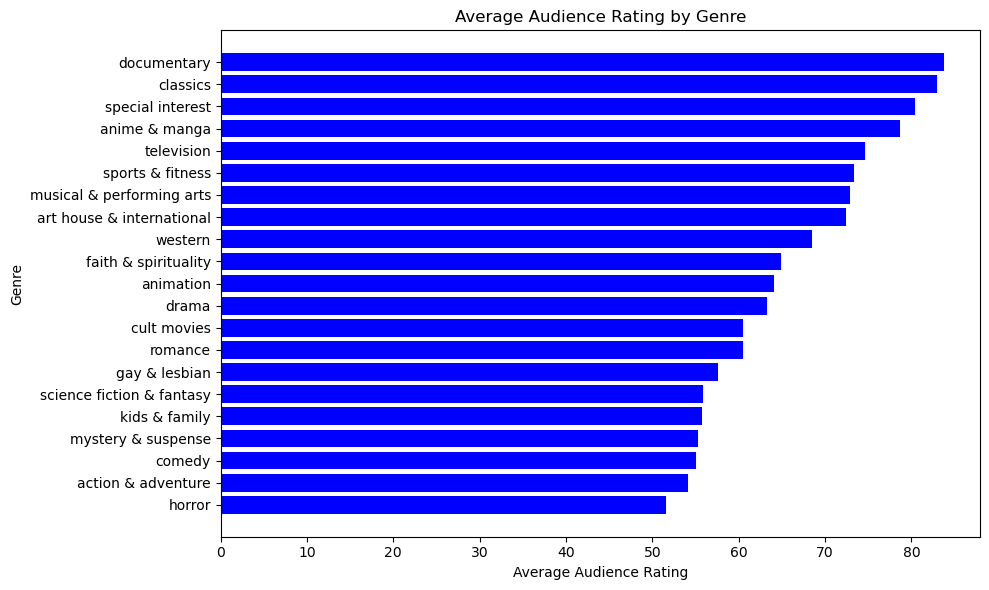

In [61]:
# Sort by audience_rating descending
sorted_genre_grouped_df2 = genre_grouped_df.sort_values(by="tomatometer_rating", ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(y=sorted_genre_grouped_df2["genres"], width=sorted_genre_grouped_df2["tomatometer_rating"], color='blue')
plt.xlabel("Average Audience Rating")
plt.ylabel("Genre")
plt.title("Average Audience Rating by Genre")
plt.gca().invert_yaxis()  # Optional: highest rating appears at the top
plt.tight_layout()
plt.show()

The top rated genres by tomato meter ratings are `documentary` , `classics` , `special interest` and `anime and manga`.

The least rated genres by tomato meter  ratings are `horror` followed by `action and adventure` , `comedy` and `mystery and suspense` respectively.

### **Content Rating vs ROI EDA**

#### **Exploratory Data Analysis (EDA)**

EDA involves visualizing and summarizing datasets to understand structure, detect anomalies, and explore variable relationships. This helps prepare clean and reliable data for deeper analysis or modeling. This section focuses on exploring the relationship between `content rating` and `return on investment`

We will be using the merged `rotten tomatoes` and `the number movies budget` dataframe for this analysis.

#### **Summarizing Dataframe**

Summarizing the dataset gives an overall view of its structure, including the number of records, types of columns, presence of missing values, and mix of categorical and numerical data. This initial step is important for understanding the completeness and quality of the data, identifying what types of analysis are appropriate, and planning any necessary cleaning or preprocessing before deeper exploration. In this section we will be summarizing the merged dataframe containing relevant columns.

In [38]:
## summary statistics of the cleaned dataframe
rel_joined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6061 entries, 0 to 6060
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ROI (%)         6061 non-null   float64
 1   content_rating  6061 non-null   object 
dtypes: float64(1), object(1)
memory usage: 94.8+ KB


The dataset has 6,061 rows and 2 columns, with no missing values. It contains both categorical and numerical columns, which determines the methods used for analysis

#### **Describing Numerical Columns**

Describing the `ROI%` column provides a clear overview of its' typical values, variability, and distribution. It helps identify outliers, detect skewness, and understand how these variables compare in scale. This foundational insight is essential for making informed analysis decisions, guiding further data exploration, and ensuring accurate modeling.

In [39]:
## describing the cleaned dataframe
rel_joined_df.describe()

,ROI (%)
count,6061.000000
mean,448.614420
std,1817.558207
min,-100.000000
25%,-19.500000
50%,103.000000
75%,312.000000
max,49775.000000


The average ROI percentage is approximately 448.61%, with values ranging from a complete loss at -100% to a very high gain of 49,775%. The median sits at 103%, suggesting that half the values are above this point and half below, though the high maximum skews the mean upward. The first quartile (25%) is -19.5, and the third quartile (75%) is 312, indicating that most values are concentrated in the lower and middle ranges but with a few exceptionally high returns.

#### Plotting a Box Plot 
The aim of ploting a box plot in this case is to check for the presence of outliers. outliers will skew the mean leading to unreliable conclusions.

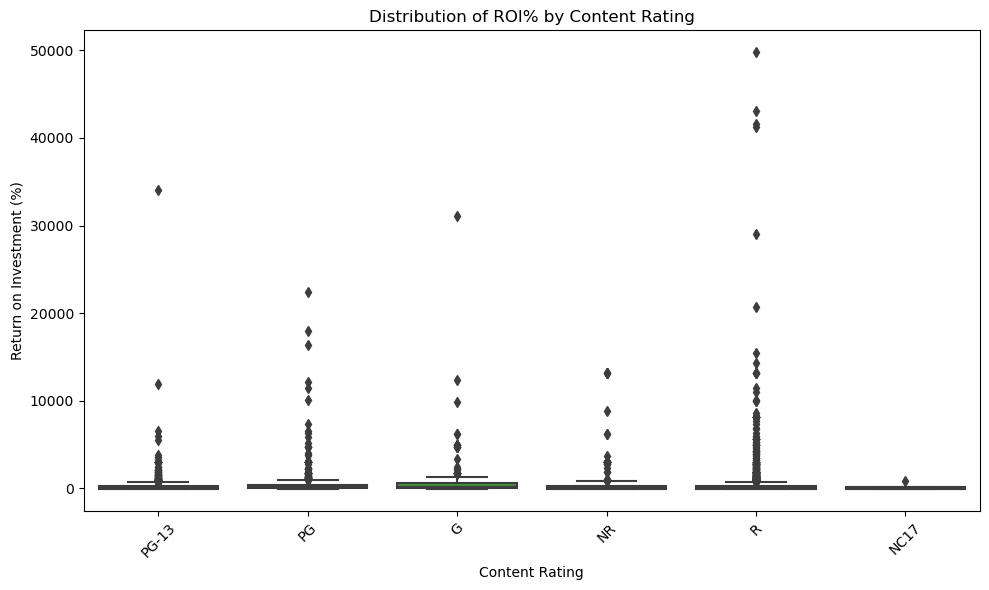

In [40]:
# Create a box plot of ROI% by content_rating
plt.figure(figsize=(10, 6))
sns.boxplot(x='content_rating', y='ROI (%)', data=rel_joined_df)

plt.title('Distribution of ROI% by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Return on Investment (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From the box plot we see that there are very many outliers. We proceed to handle the outliers.

In [41]:
def detect_and_remove_roi_outliers(df=rel_joined_df, roi_col='ROI (%)', group_col='content_rating'):
    """
    Detects and removes ROI outliers within each content rating group using the IQR method.

    Returns:
    - cleaned_df: DataFrame with outliers removed.
    - outliers_df: DataFrame containing only the outliers.
    """
    cleaned_rows = []
    outlier_rows = []

    for category in df[group_col].unique():
        group = df[df[group_col] == category]
        Q1 = group[roi_col].quantile(0.25)
        Q3 = group[roi_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter inliers and outliers
        inliers = group[(group[roi_col] >= lower_bound) & (group[roi_col] <= upper_bound)]
        outliers = group[(group[roi_col] < lower_bound) | (group[roi_col] > upper_bound)]

        cleaned_rows.append(inliers)
        outlier_rows.append(outliers)
        

    cleaned_df = pd.concat(cleaned_rows).reset_index(drop=True)
    outliers_df = pd.concat(outlier_rows).reset_index(drop=True)
    return cleaned_df, outliers_df
cleaned_df2,outlier_df=detect_and_remove_roi_outliers()
cleaned_df2

,ROI (%),content_rating
0,553.0,PG-13
1,155.0,PG-13
2,-57.0,PG-13
3,324.0,PG-13
4,583.0,PG-13
...,...,...
5450,-94.0,NC17
5451,214.0,NC17
5452,-65.0,NC17
5453,-37.0,NC17


We created a function that calculates the upper and lower bounds for the ROI under each content rating category. After calculating the bounds, it uses them to extract 2 dataframes; one for only outliers and the other which has no outliers. 

In [42]:
# checking for the number of dropped records
print(f"outlier records :{len(outlier_df)}")
print(f"inlier records :{len(cleaned_df2)}")

outlier records :606
inlier records :5455


Since the mumber of records in the dataframe with only outlier values is less significant compared to the dataframe with no outliers, we proceed to work with the dataframe with no outliers.

After extracting the dataframe with no outliers we aggregate the dataframe by the mean of ROI percentage of content ratings categories. 

In [43]:
# grouping the df
grouped_cleaned_df =cleaned_df2.groupby("content_rating")["ROI (%)"].mean().reset_index().sort_values(by="ROI (%)",ascending=False)
grouped_cleaned_df

,content_rating,ROI (%)
0,G,267.366667
3,PG,180.284994
4,PG-13,136.382406
2,NR,103.515588
5,R,102.978952
1,NC17,12.500000


#### **Plotting a Bar Plot**

This section focuses on plotting a bar plot of content rating vs the return on investment to check the distribution of the return on investment on the content rating categories.A bar plot is used to view the distribution of values of interest against different categories, making it easy to compare performance, spot patterns, and identify areas for improvement. This helps us develop data-driven solutions based on the insights revealed by the plot. 

Text(0.5, 1.0, 'content rating vs avg ROI%')

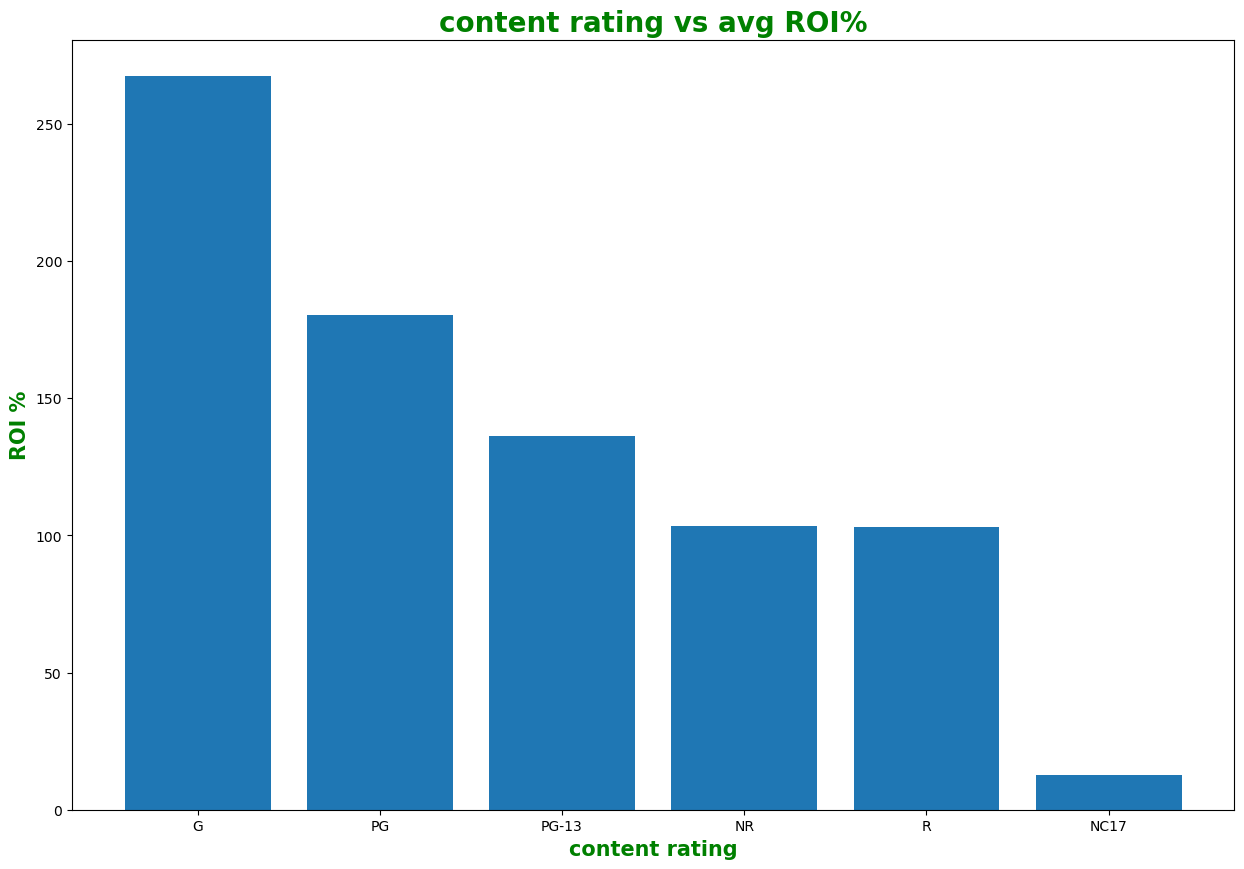

In [44]:
# plot a bar plot
plt.figure(figsize=(15,10))
plt.bar(grouped_cleaned_df["content_rating"],grouped_cleaned_df["ROI (%)"])
plt.xlabel("content rating",fontsize=15,color="g",fontweight="bold")
plt.ylabel("ROI %",fontsize=15,fontweight="bold",color="g")
plt.title("content rating vs avg ROI%",fontsize=20,fontweight="bold",color="g")


We observe that movies rated **G** tend to have a higher return on investment compared to other categories. Movies rated **PG** and **PG-13** show an average return on investment relative to the rest. In contrast, movies rated **R** and **NR** exhibit lower returns with movies rated **NC17** having very low returns relative to the others.

##### Vincent


Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

##### Chris
Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

##### Vihaan
Same as before do not touch anything outside of these cells add as many cells as you would like between here and the next name. Do not edit anythin in the document if you need to edit anything write it down and tell me about it later

#### *2. Hypothesis Testing*  

## 【4】**Statistical Tests**  
Statistical tests are formal mathematical procedures used to make decisions or inferences about data. They help us quantify uncertainty and make data-driven conclusions, rather than relying on intuition or guesswork.

### **Objective** 

Conduct statistical test to determine whether there is a statistically significant difference in **ROI (%)** across different **content rating categories**

### **Methodology** 
we will do a hypothesis test to fullfill our objective

We will use **One-Way ANOVA** or **Welch’s ANOVA Model** for this particular test since we do have several **content rating categories**

Before performing the ANOVA, we test for the assumption of Homogeneity which takes assumption of equal variances

We compute this Homogeneity using **Levene's Test**. 

**Levene's Test Hypothesis**
- Null Hypothesis : The variances of all groups are equal.
- Alternative Hypothesis : At least one group has a different variance.

If **Levene’s Test p-value > 0.05**, then it means variances are equal and we can proceed with **One-Way ANOVA** otherwise it means variance are not equal and we shall progress to use **Welch’s ANOVA Model**

**Anova Hypothesis**

- Null Hypothesis (H₀): The means of ROI (%) are equal across all content rating categories

- Alternative Hypothesis (H₁):** At least one content rating group has a different mean ROI (%)



In [45]:
from scipy.stats import f_oneway
from scipy.stats import levene
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Assume your grouped_df has two columns: 'x' (categorical), 'y' (numerical)
x="content_rating"
y="ROI (%)"

# Separate the numerical values into groups based on the categorical variable
groups = []
for category in cleaned_df2[x].unique():
    group = cleaned_df2[cleaned_df2[x] == category][y]
    groups.append(group)
# Levene's Test (checks equal variances)
levene_stat, levene_p = levene(*groups)
print(f"\nLevene’s Test:")
print(f"Statistic: {levene_stat:.3f}")
print(f"P-value: {levene_p:.5f}")
if levene_p < 0.05:
    print(" Variances are significantly different — consider using Welch's ANOVA.")
else:
    print("Variances are equal — One-way ANOVA is appropriate.")


Levene’s Test:
Statistic: 12.846
P-value: 0.00000
 Variances are significantly different — consider using Welch's ANOVA.


#### *Interpretation*  

Since Levene’s Test showed that variances are significantly different, you cannot use a One-Way ANOVA. Instead we will work with Welch’s ANOVA using the statsmodels.

We shall progress import the necessary libary and appropriate code.

In [46]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Welch's ANOVA using Ordinary Least Squares (OLS) and robust covariance
model = smf.ols('Q("ROI (%)") ~ C(content_rating)', data=cleaned_df2).fit()

# Perform Welch ANOVA (type=2 for unbalanced design, robust for unequal variances)
anova_table = sm.stats.anova_lm(model, typ=2, robust='hc3')

# Display results
print(anova_table)

                         sum_sq      df          F        PR(>F)
C(content_rating)  6.184320e+06     5.0  27.987922  4.294667e-28
Residual           2.408065e+08  5449.0        NaN           NaN


#### *Interpretation of Welch's ANOVA Results*  

The ANOVA results for testing whether ROI (%) differs significantly across different content ratings are summarized as follows:

F-statistic**: 27.99  
p-value**: 4.29 × 10⁻²⁸  

### **Conclusion**  
Since the p-value is much smaller than Alpha of 0.05, we reject the null hypothesis. This provides strong statistical evidence that the mean ROI (%) significantly differs across at least one pair of content rating categories.

Content rating appears to have a significant effect on movie return on investment (ROI).

## 【4】**Business Recommendations**  

## 【5】**Limitations of Our Analysis**  